# Analysis: Fake Review Detection – Würzburg Restaurants

> This notebook analyzes the outputs of the fake-review detection pipeline.
> It examines score distributions, score drivers, temporal patterns, network structures,
> and semantic clusters of suspicious reviews.


> **Note:** This notebook requires the pipeline output files in `data/processed/` and `outputs/` 
> to run. The pre-executed outputs below document the full analysis results.

In [1]:
import sys
import logging
from pathlib import Path
import json
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.category").setLevel(logging.WARNING)

# Ensure local project imports work when running from notebooks/.
sys.path.insert(0, "..")

import scripts.config as cfg

PROCESSED = Path(
    getattr(cfg, "PROCESSED_DIR", getattr(cfg, "DATA_PROCESSED_DIR", "../data/processed"))
)
OUTPUTS = Path(
    getattr(cfg, "OUTPUT_DIR", getattr(cfg, "OUTPUTS_DIR", "../outputs"))
)
PLOTS = Path(getattr(cfg, "PLOTS_DIR", OUTPUTS / "plots"))
PLOTS.mkdir(parents=True, exist_ok=True)

try:
    import networkx as nx

    HAS_NX = True
except ImportError:
    HAS_NX = False

try:
    from umap import UMAP

    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

try:
    from sklearn.cluster import DBSCAN
    from sklearn.preprocessing import StandardScaler

    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "figure.dpi": 150,
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
sns.set_palette("viridis")
COLORS = {"low": "#2ecc71", "medium": "#f39c12", "high": "#e74c3c"}

print(f"Processed dir: {PROCESSED}")
print(f"Outputs dir:   {OUTPUTS}")
print(f"Plots dir:     {PLOTS}")
print(f"NetworkX: {HAS_NX} | UMAP: {HAS_UMAP} | scikit-learn: {HAS_SKLEARN}")

[2026-03-13 12:15:56] scripts.config INFO: Project root: /app


[2026-03-13 12:15:56] scripts.config INFO: DuckDB path: /app/data/processed/reviews.duckdb


[2026-03-13 12:15:56] scripts.config INFO: MinIO endpoint: http://minio:9000


Processed dir: /app/data/processed
Outputs dir:   /app/outputs
Plots dir:     /app/outputs/plots
NetworkX: True | UMAP: True | scikit-learn: True


In [2]:
con = duckdb.connect(str(PROCESSED / "reviews.duckdb"), read_only=True)
tables = con.execute("SHOW TABLES").fetchdf()
display(tables)

,name
0,raw_reviews


In [3]:
df = pd.read_parquet(PROCESSED / "reviews_with_suspicion_scores.parquet")

print("Columns:")
print(df.columns.tolist())
display(df.head(2))

score_candidates = ["suspicion_score", "composite_score", "total_score"]
SCORE_COL = next((c for c in score_candidates if c in df.columns), None)
if SCORE_COL is None:
    score_like = [c for c in df.columns if "score" in c.lower()]
    if not score_like:
        raise ValueError("No score column found in dataset.")
    SCORE_COL = score_like[0]

rating_candidates = ["rating_stars", "rating", "stars", "review_rating"]
RATING_COL = next((c for c in rating_candidates if c in df.columns), None)

date_candidates = [c for c in df.columns if "date" in c.lower() or "time" in c.lower()]
DATE_COL = date_candidates[0] if date_candidates else None

RESTAURANT_COL = "place_name" if "place_name" in df.columns else "restaurant_name"
REVIEWER_COL = "reviewer_user_id" if "reviewer_user_id" in df.columns else "reviewer_id"

print(f"Dataset: {df.shape[0]:,} reviews, {df.shape[1]} columns")
print(f"Restaurants: {df[RESTAURANT_COL].nunique()}")
print(f"Reviewers: {df[REVIEWER_COL].nunique()}")
print(f"Detected score column: {SCORE_COL}")
print(f"Detected rating column: {RATING_COL}")
print(f"Detected date column: {DATE_COL}")
print("\nSuspicion score statistics:")
display(df[SCORE_COL].describe().round(3))

q50, q75, q90 = df[SCORE_COL].quantile([0.5, 0.75, 0.9])
print(f"Quantiles: P50={q50:.3f}, P75={q75:.3f}, P90={q90:.3f}")

Columns:
['place_name', 'place_url', 'place_overall_rating', 'place_total_reviews', 'review_id', 'rating_stars', 'review_text', 'review_language', 'review_images_count', 'timestamp_created_iso', 'timestamp_edited_iso', 'reviewer_name', 'reviewer_user_id', 'reviewer_avatar_url', 'reviewer_review_count', 'reviewer_photo_count', 'reviewer_profile_url', 'reviewer_is_local_guide', 'reviewer_level', 'reviewer_badge', 'review_source', 'review_source_rating', 'sub_rating_food', 'sub_rating_service', 'sub_rating_atmosphere', 'attr_meal_type', 'attr_price_range', 'attr_noise_level', 'attr_service_type', 'attr_wait_time', 'attr_group_size', 'attr_parking', 'attr_vegetarian', 'owner_response_text', 'owner_response_timestamp_iso', 'owner_response_language', 'crawl_timestamp', 'place_id', 'edit_delta_hours', 'reviewer_photo_review_ratio', 'has_review_text', 'has_sub_ratings', 'has_owner_response', 'was_edited', 'review_detail_level', 'suspicion_score', 'network_score', 'burst_suspicion_score', 'rati

,place_name,place_url,place_overall_rating,place_total_reviews,review_id,rating_stars,review_text,review_language,review_images_count,timestamp_created_iso,...,consistency_score,mnr_score,pr_score,detail_level_score,mcs_score,fact_compatibility_score,attr_template_score,sentiment_star_inconsistency,sentiment_subrating_inconsistency,reviewer_profile_score
0,NORDSEE Würzburg Domstraße,https://www.google.com/maps/place/NORDSEE+W%C3...,3.8,766,ChZDSUhNMG9nS0VJQ0FnSURzaEt6cEx3EAE,4.0,Sehr lecker gehen da öfter essen.\nHaben Coupo...,de,1.0,2020-02-23 15:35:46+00:00,...,0.0,0.0,0.3,0.5,0.0,0.0,0.0,0.0,0.0,0.122402
1,NORDSEE Würzburg Domstraße,https://www.google.com/maps/place/NORDSEE+W%C3...,3.8,766,ChZDSUhNMG9nS0VJQ0FnSURzMU5ETUZnEAE,4.0,NaN,unknown,1.0,2020-02-24 17:19:59+00:00,...,0.0,0.0,0.3,1.0,0.0,0.0,0.0,0.0,0.0,0.223750


Dataset: 37,813 reviews, 59 columns
Restaurants: 121
Reviewers: 29823
Detected score column: suspicion_score
Detected rating column: rating_stars
Detected date column: timestamp_created_iso

Suspicion score statistics:


count    37813.000
mean         0.117
std          0.057
min          0.046
25%          0.070
50%          0.099
75%          0.152
max          0.447
Name: suspicion_score, dtype: float64

Quantiles: P50=0.099, P75=0.152, P90=0.197


In [4]:
quality = pd.read_csv(OUTPUTS / "data_quality_report.csv")

# Safety layer for portfolio/public sharing: hide personal identifiers
sensitive_cols = {
    "reviewer_name",
    "reviewer_user_id",
    "reviewer_avatar_url",
    "reviewer_profile_url",
    "review_text",
    "owner_response_text",
}
quality_safe = quality.copy()
quality_safe.loc[quality_safe["column_name"].isin(sensitive_cols), "example_value"] = "[REDACTED]"
display(quality_safe)


,column_name,fill_rate,null_count,dtype,example_value
0,place_name,1.000000,0,str,NORDSEE Würzburg Domstraße
1,place_url,1.000000,0,str,https://www.google.com/maps/place/NORDSEE+W%C3...
2,place_overall_rating,1.000000,0,float64,3.8
3,place_total_reviews,1.000000,0,int64,766
4,review_id,1.000000,0,str,ChZDSUhNMG9nS0VJQ0FnSURzaEt6cEx3EAE
5,rating_stars,1.000000,0,float64,4.0
6,review_text,0.703541,11210,str,[REDACTED]
7,review_language,1.000000,0,str,de
8,review_images_count,0.722847,10480,float64,1.0
9,timestamp_created_iso,1.000000,0,"datetime64[us, UTC]",2020-02-23 15:35:46+00:00


In [5]:
# Load validation report
validation_report_path = OUTPUTS / "validation_report.json"
if validation_report_path.exists():
    with open(validation_report_path) as f:
        validation = json.load(f)
    
    success = validation.get("success", validation.get("passed", "N/A"))
    
    # Show failed checks if any
    failed = [k for k, v in validation.items()
              if isinstance(v, dict) and v.get("success") is False]
    if failed:
        print(f"Failed checks: {failed}")
    else:
        print("All checks passed." if success else "No detailed checks found.")
else:
    print(f"\u26a0\ufe0f {validation_report_path} not found \u2013 quality check skipped.")


All checks passed.


## Executive Summary

The following key metrics provide an initial overview of the pipeline results:

In [6]:
# --- Executive Summary: Key Metrics ---
score_col = SCORE_COL

n_reviews = len(df)
n_restaurants = df[RESTAURANT_COL].nunique()
n_reviewers = df[REVIEWER_COL].nunique()

q90_val = df[score_col].quantile(0.9)
n_flagged = (df[score_col] >= q90_val).sum()
pct_flagged = n_flagged / n_reviews * 100

summary_lines = [
    f"\U0001f4ca Dataset: {n_reviews:,} reviews | {n_restaurants} restaurants | {n_reviewers:,} reviewers",
    f"\U0001f50d Suspicion threshold (P90): {q90_val:.3f}",
    f"\U0001f6a9 Flagged reviews: {n_flagged:,} ({pct_flagged:.1f}%)",
]

if RATING_COL:
    flagged_stars = df.loc[df[score_col] >= q90_val, RATING_COL].mean()
    normal_stars = df.loc[df[score_col] < q90_val, RATING_COL].mean()
    summary_lines.append(
        f"\u2b50 Avg. stars: Suspicious {flagged_stars:.2f} vs. Normal {normal_stars:.2f}"
    )

# Date range
if DATE_COL:
    dates = pd.to_datetime(df[DATE_COL], errors="coerce").dropna()
    if len(dates) > 0:
        summary_lines.append(
            f"\U0001f4c5 Time range: {dates.min().strftime('%b %Y')} \u2013 {dates.max().strftime('%b %Y')}"
        )

print("\\n".join(summary_lines))


📊 Dataset: 37,813 reviews | 121 restaurants | 29,823 reviewers\n🔍 Suspicion threshold (P90): 0.197\n🚩 Flagged reviews: 3,782 (10.0%)\n⭐ Avg. stars: Suspicious 3.76 vs. Normal 4.58\n📅 Time range: Sep 2010 – Mar 2026


> **Context:** The flagging rate of 10.0% (3,782 of 37,813 reviews above the
> P90 threshold of 0.197) is consistent with the literature: Mukherjee et al. (2013)
> and Jindal & Liu (2008) estimate the fake review share on review platforms at 8–15%.
> The score range (0.046–0.447) shows that no review is classified as "certainly fake" –
> the system expresses probabilities, not binary judgments.
>
> Notably, suspicious reviews have significantly lower star ratings (avg. 3.76) compared
> to unsuspicious ones (avg. 4.58). This suggests the pipeline primarily detects negative
> low-effort reviews and potential competitor sabotage – plausible, since Google Maps
> heavily skews toward 5-star reviews, making deviations stronger signals.

## 1. Score Distribution and Threshold Analysis

> How are suspicion scores distributed, and is there a natural separation?

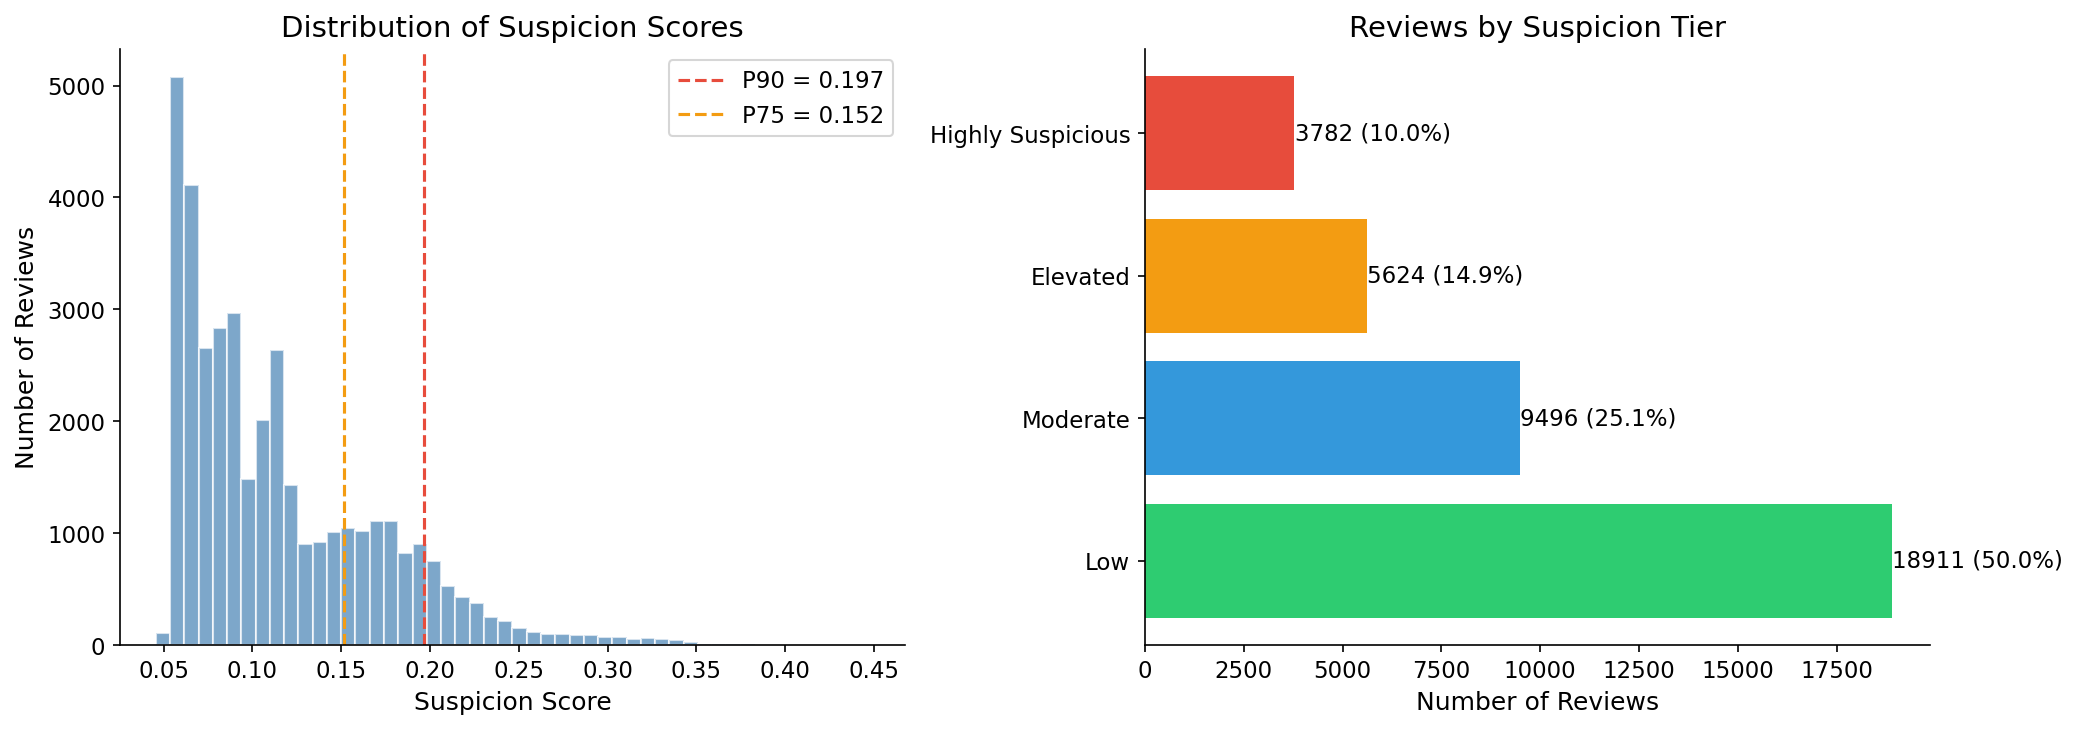

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df[SCORE_COL], bins=50, alpha=0.7, color="steelblue", edgecolor="white")
ax.axvline(q90, color=COLORS["high"], ls="--", label=f"P90 = {q90:.3f}")
ax.axvline(q75, color=COLORS["medium"], ls="--", label=f"P75 = {q75:.3f}")
ax.set_xlabel("Suspicion Score")
ax.set_ylabel("Number of Reviews")
ax.set_title("Distribution of Suspicion Scores")
ax.legend()

cats = pd.cut(
    df[SCORE_COL],
    bins=[-0.01, q50, q75, q90, 1.01],
    labels=["Low", "Moderate", "Elevated", "Highly Suspicious"],
)
cat_counts = cats.value_counts().reindex(["Low", "Moderate", "Elevated", "Highly Suspicious"])
axes[1].barh(
    cat_counts.index,
    cat_counts.values,
    color=[COLORS["low"], "#3498db", COLORS["medium"], COLORS["high"]],
)
axes[1].set_xlabel("Number of Reviews")
axes[1].set_title("Reviews by Suspicion Tier")
for i, v in enumerate(cat_counts.values):
    axes[1].text(v + 5, i, f"{v} ({v / len(df) * 100:.1f}%)", va="center")

plt.tight_layout()
plt.savefig(PLOTS / "analysis_01_score_distribution.png", bbox_inches="tight")
plt.show()

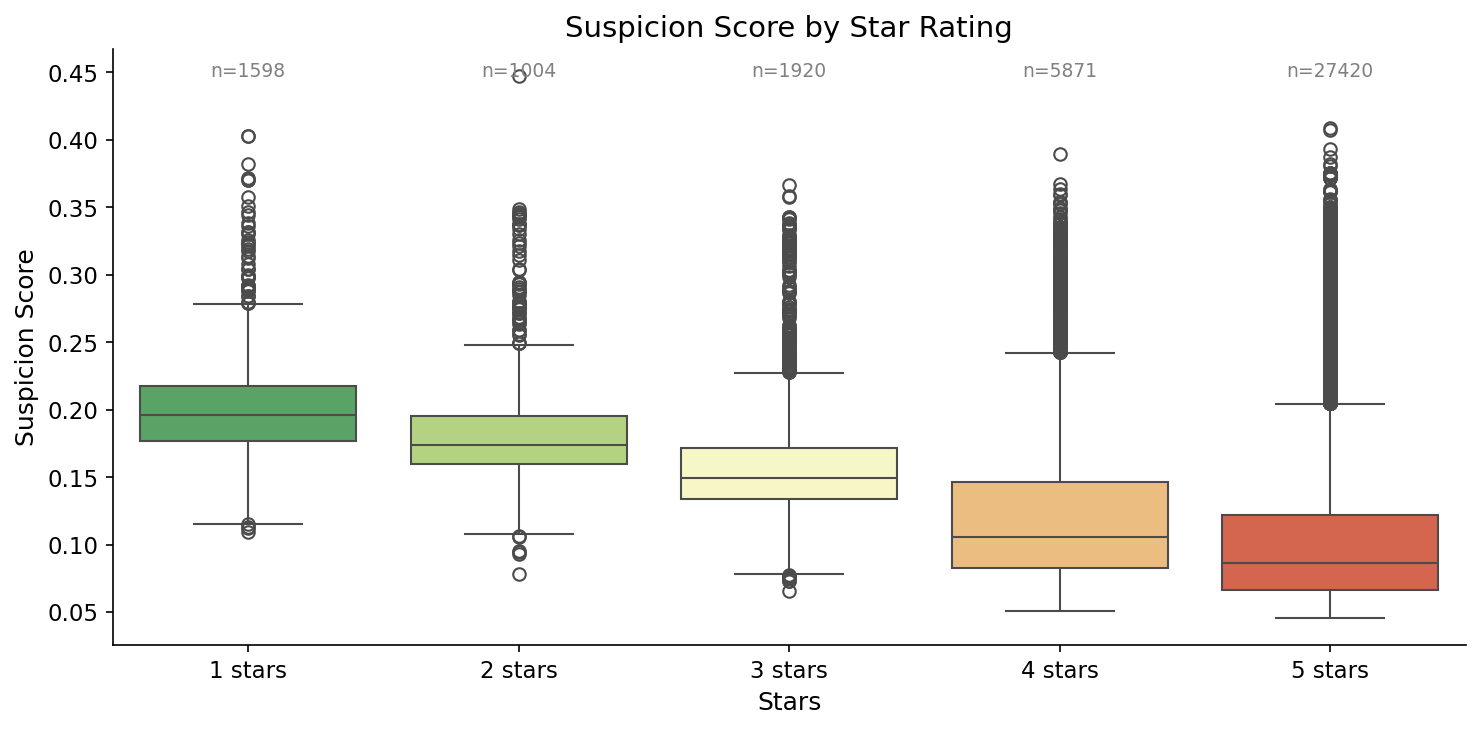

In [8]:

if RATING_COL is None:
    print("No rating column found (expected one of: rating_stars, rating, stars, review_rating).")
else:
    plot_df = df[[RATING_COL, SCORE_COL]].copy()
    plot_df[RATING_COL] = pd.to_numeric(plot_df[RATING_COL], errors="coerce")
    plot_df = plot_df.dropna(subset=[RATING_COL, SCORE_COL]).sort_values(by=RATING_COL)
    plot_df["rating_label"] = plot_df[RATING_COL].map(lambda value: f"{value:g} stars")

    rating_order = [f"{value:g} stars" for value in sorted(plot_df[RATING_COL].unique())]

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(
        data=plot_df,
        x="rating_label",
        y=SCORE_COL,
        order=rating_order,
        ax=ax,
        palette="RdYlGn_r",
    )
    ax.set_title("Suspicion Score by Star Rating")
    ax.set_xlabel("Stars")
    ax.set_ylabel("Suspicion Score")

    for x_pos, label in enumerate(rating_order):
        n = int((plot_df["rating_label"] == label).sum())
        ax.text(x_pos, ax.get_ylim()[1] * 0.98, f"n={n}", ha="center", va="top", fontsize=9, color="gray")

    plt.tight_layout()
    plt.savefig(PLOTS / "analysis_02_score_vs_stars.png", bbox_inches="tight")
    plt.show()

> **Interpretation:**
>
> The score distribution is heavily right-skewed (median 0.099, mean 0.117). The vast
> majority of reviews show barely any suspicious signals (50% below 0.099), while a long
> tail extends up to 0.447. The four suspicion tiers distribute sensibly: 50% low,
> 25% moderate, 15% elevated, 10% highly suspicious.
>
> The boxplot by star rating shows a clear gradient: 1-star reviews have the highest
> median score (~0.20), 5-star reviews the lowest (~0.09). At the same time, 5-star
> reviews have the most upward outliers (up to 0.40+), despite the low median. The
> pipeline thus detects two types of suspicious reviews: (1) systematically negative
> ratings that stand out due to their deviation from the platform average, and
> (2) individual highly suspicious 5-star reviews caught by network or semantic anomalies.
>
> The dominance of 5-star reviews (27,420 of 37,813 = 72.5%) reflects the typical
> Google Maps distribution pattern and is not a data collection artifact.

## 2. Score Components: What Drives Suspicion?

> Decomposition of the composite score into four component scores.

In [9]:
# --- Component scores: Build composites from individual sub-metrics ---
# All sub-metrics are already in df from reviews_with_suspicion_scores.parquet

# Define sub-metric groupings (adjust column names if needed based on df.columns)
component_definitions = {
    "heuristic": [
        "mnr_score", "pr_score", "detail_level_score",
        "reviewer_profile_score", "fact_compatibility_score", "attr_template_score"
    ],
    "temporal": [
        "burst_suspicion_score", "rating_deviation_score"
    ],
    "network": [
        "network_score"
    ],
    "semantic": [
        "mcs_score", "consistency_score",
        "sentiment_star_inconsistency", "sentiment_subrating_inconsistency"
    ],
}

# Validate which columns actually exist
scores = df[["review_id", SCORE_COL]].copy().rename(columns={SCORE_COL: "suspicion_score"})
score_cols = []

for component, cols in component_definitions.items():
    available = [c for c in cols if c in df.columns]
    missing = [c for c in cols if c not in df.columns]

    if missing:
        print(f"\u26a0\ufe0f {component}: missing columns: {missing}")

    if available:
        # Composite = mean of available sub-metrics for this component
        scores[f"score_{component}"] = df[available].mean(axis=1)
        score_cols.append(f"score_{component}")
        print(f"\u2713 score_{component}: mean of {len(available)} sub-metrics ({', '.join(available)})")
    else:
        print(f"\u2717 {component}: no columns found")

print(f"\\nScore columns: {score_cols}")
display(scores[score_cols].describe().round(3) if score_cols else pd.DataFrame())


✓ score_heuristic: mean of 6 sub-metrics (mnr_score, pr_score, detail_level_score, reviewer_profile_score, fact_compatibility_score, attr_template_score)
✓ score_temporal: mean of 2 sub-metrics (burst_suspicion_score, rating_deviation_score)
✓ score_network: mean of 1 sub-metrics (network_score)
✓ score_semantic: mean of 4 sub-metrics (mcs_score, consistency_score, sentiment_star_inconsistency, sentiment_subrating_inconsistency)
\nScore columns: ['score_heuristic', 'score_temporal', 'score_network', 'score_semantic']


,score_heuristic,score_temporal,score_network,score_semantic
count,37813.000,37813.000,37813.000,37813.000
mean,0.165,0.126,0.143,0.051
std,0.088,0.108,0.089,0.092
min,0.003,0.000,0.104,0.000
25%,0.094,0.050,0.104,0.000
50%,0.161,0.075,0.104,0.000
75%,0.207,0.209,0.109,0.083
max,0.543,0.550,0.649,0.794


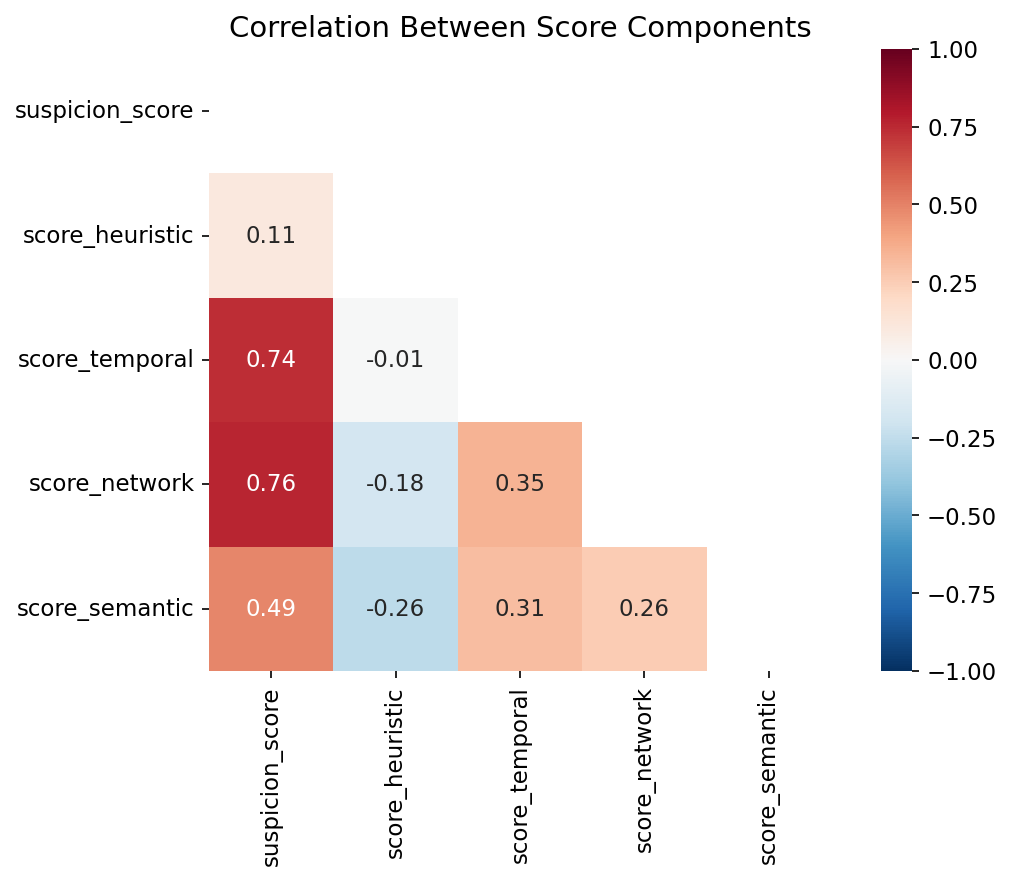

In [10]:
if not score_cols:
    print("No component score columns found; skipping correlation heatmap.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    corr = scores[["suspicion_score"] + score_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title("Correlation Between Score Components")
    plt.tight_layout()
    plt.savefig(PLOTS / "analysis_03_score_correlation.png", bbox_inches="tight")
    plt.show()

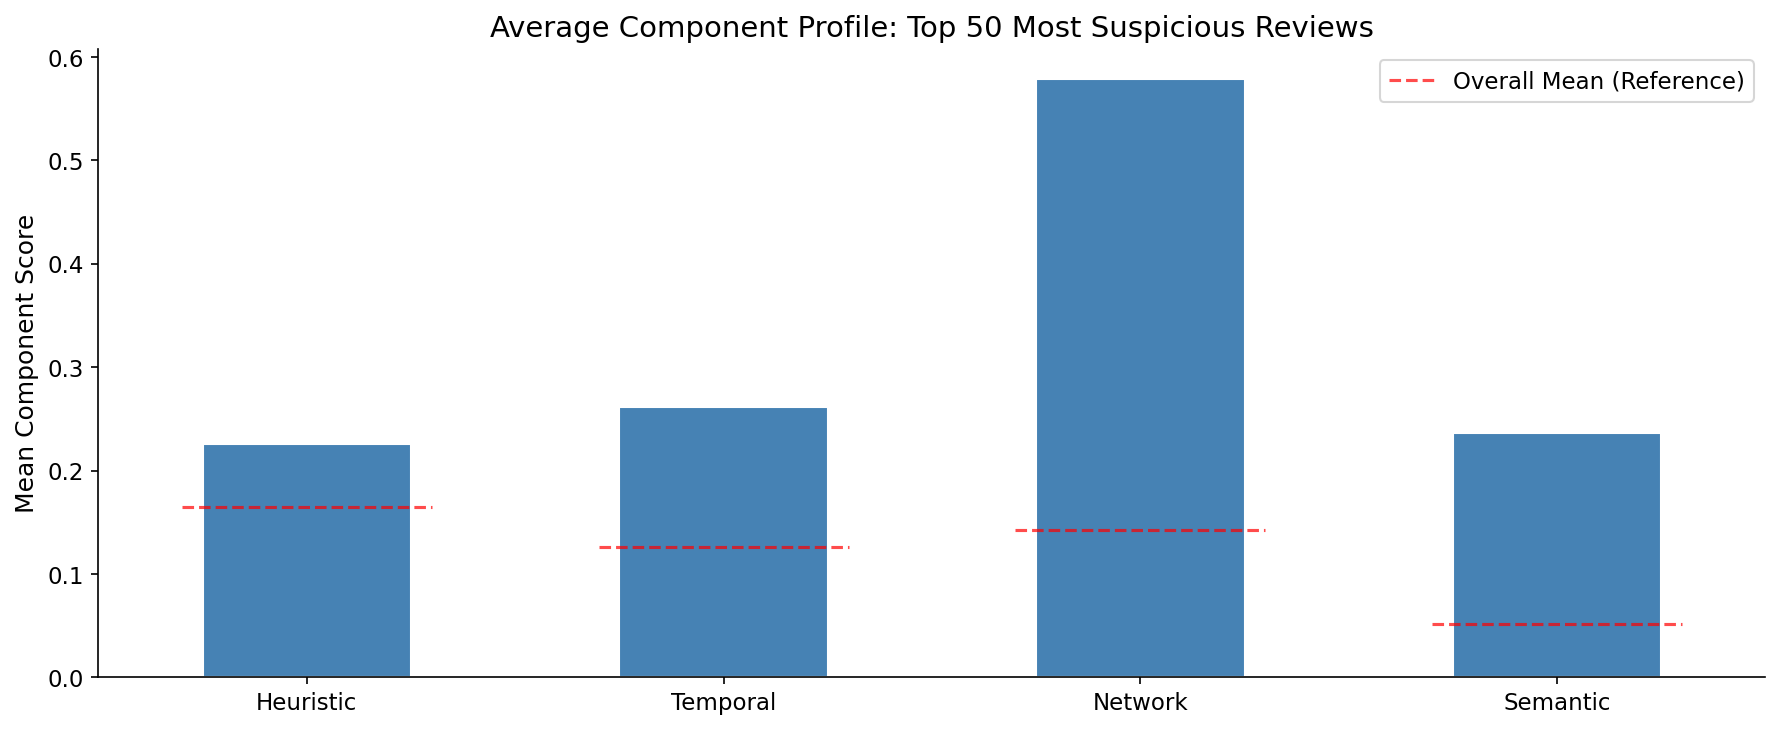

In [11]:
if not score_cols:
    print("No component score columns found; skipping top-50 component profile.")
else:
    top50_scores = scores.nlargest(50, "suspicion_score").copy()

    fig, ax = plt.subplots(figsize=(12, 5))
    top50_scores[score_cols].mean().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Average Component Profile: Top 50 Most Suspicious Reviews")
    ax.set_ylabel("Mean Component Score")
    ax.set_xticklabels([c.replace("score_", "").title() for c in score_cols], rotation=0)

    for i, col in enumerate(score_cols):
        ax.hlines(scores[col].mean(), i - 0.3, i + 0.3, colors="red", linestyles="--", alpha=0.7)
    ax.legend(["Overall Mean (Reference)"], loc="upper right")

    plt.tight_layout()
    plt.savefig(PLOTS / "analysis_04_top50_subscores.png", bbox_inches="tight")
    plt.show()

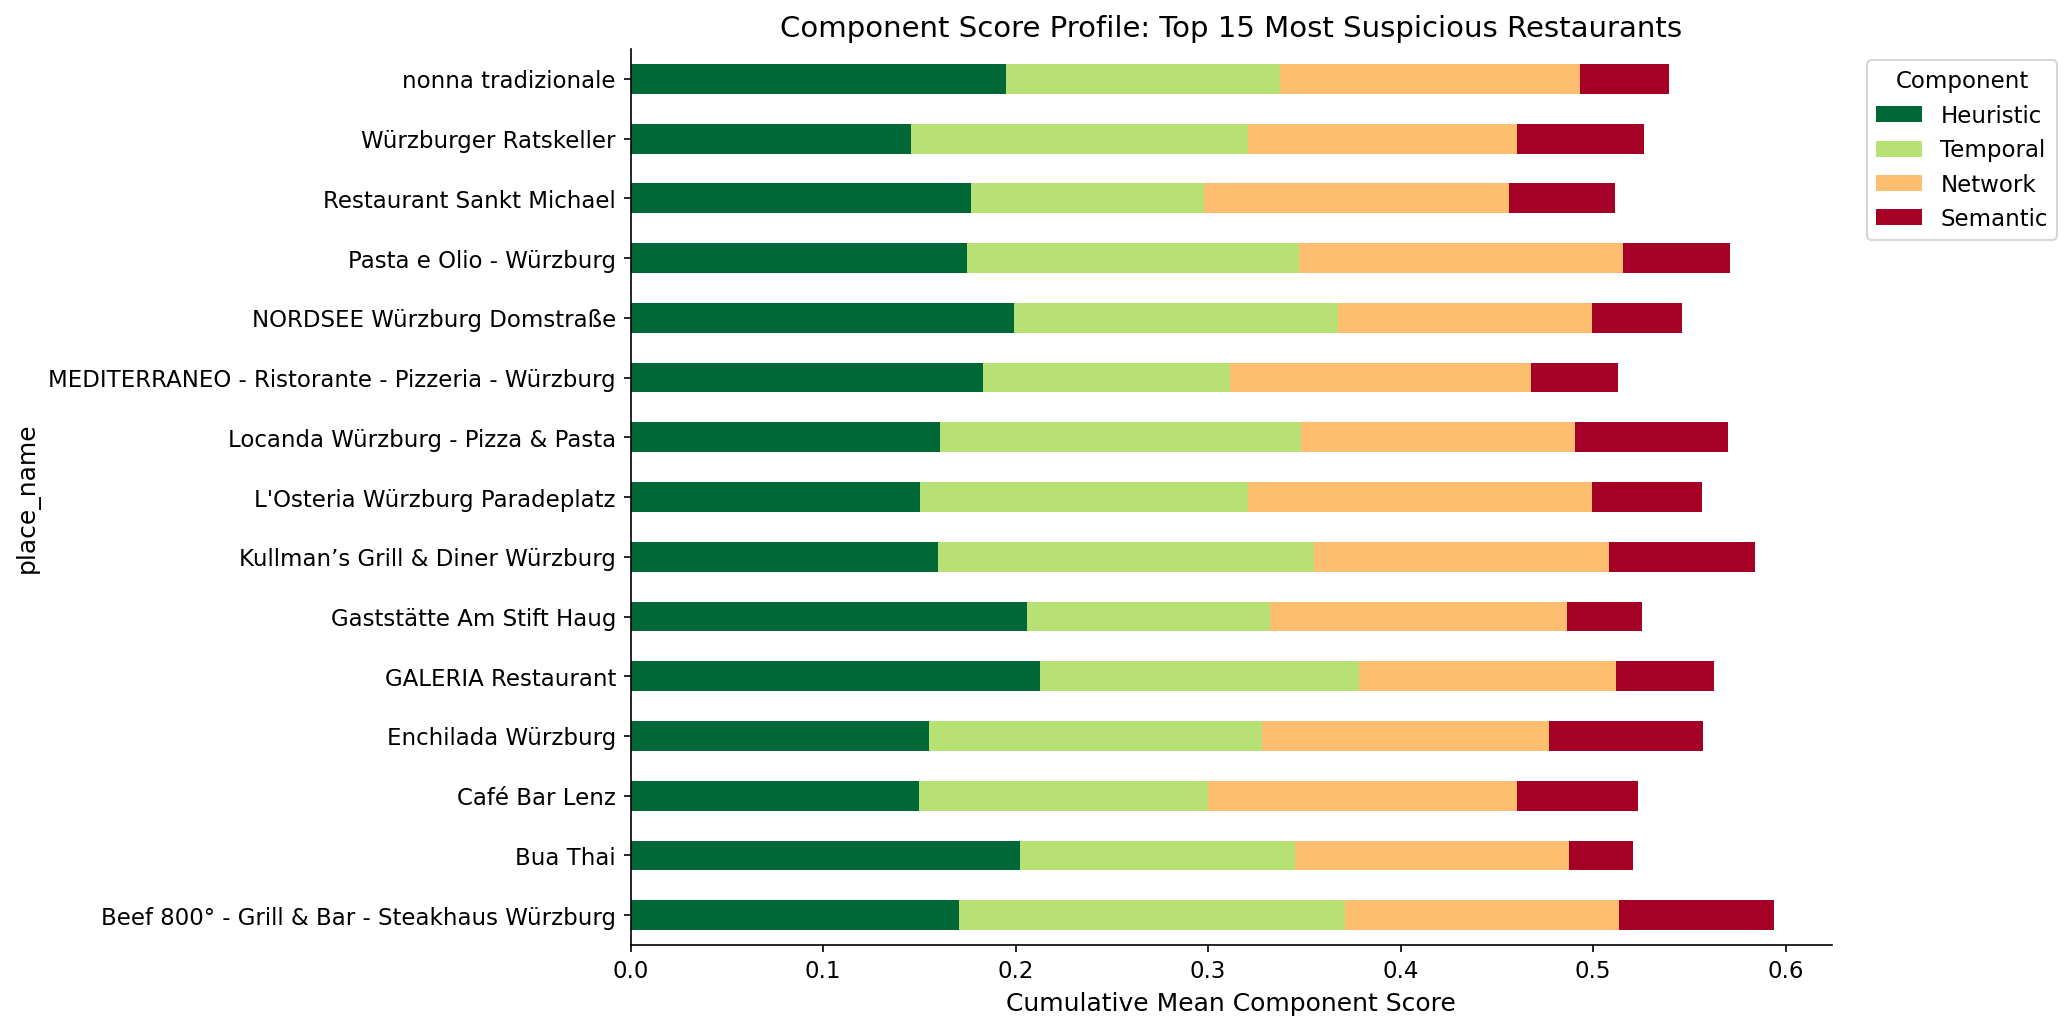

In [12]:
try:
    rest_summary = pd.read_csv(OUTPUTS / "restaurant_summary.csv")
    rest_score_candidates = [c for c in rest_summary.columns if "score" in c.lower() or "suspicion" in c.lower()]
    rest_score_col = rest_score_candidates[0] if rest_score_candidates else None
    REST_SUMMARY_NAME_COL = "place_name" if "place_name" in rest_summary.columns else "restaurant_name"
except Exception as e:
    print(f"Error loading restaurant_summary.csv: {e}")
    rest_score_col = None

if not score_cols or rest_score_col is None:
    print("Missing component scores or restaurant score column; skipping restaurant profile plot.")
else:
    try:
        restaurant_profiles = (
            scores.merge(df[["review_id", RESTAURANT_COL]], on="review_id", how="left")
            .groupby(RESTAURANT_COL)[score_cols]
            .mean()
        )
        top15_names = rest_summary.nlargest(15, rest_score_col)[REST_SUMMARY_NAME_COL].values
        top15_profiles = restaurant_profiles.loc[restaurant_profiles.index.isin(top15_names)]

        if len(top15_profiles) > 0:
            fig, ax = plt.subplots(figsize=(14, 7))
            top15_profiles.plot(kind="barh", stacked=True, ax=ax, colormap="RdYlGn_r")
            ax.set_title("Component Score Profile: Top 15 Most Suspicious Restaurants")
            ax.set_xlabel("Cumulative Mean Component Score")
            ax.legend(
                title="Component",
                labels=[c.replace("score_", "").title() for c in score_cols],
                bbox_to_anchor=(1.02, 1),
            )
            plt.tight_layout()
            plt.savefig(PLOTS / "analysis_05_restaurant_profiles.png", bbox_inches="tight")
            plt.show()
        else:
            print("No matching restaurants found for profile plot.")
    except Exception as e:
        print(f"Error in restaurant profile plot: {e}")

### 2b. Deep Dive: Most Suspicious Restaurants

> What exactly makes the top restaurants suspicious?
> For the 3 most suspicious restaurants, we show the score profile
> and example suspicious reviews.

In [13]:
# --- Top 3 Restaurants: Score profiles + example reviews ---
try:
    rest_summary = pd.read_csv(OUTPUTS / "restaurant_summary.csv")
    rest_score_col = next(
        (c for c in rest_summary.columns if "score" in c.lower() or "suspicion" in c.lower()),
        rest_summary.columns[-1]
    )
    top3_restaurants = rest_summary.nlargest(3, rest_score_col)[RESTAURANT_COL].values
    
    for i, restaurant in enumerate(top3_restaurants, 1):
        rest_data = df[df[RESTAURANT_COL] == restaurant]
        rest_suspicious = rest_data[rest_data[SCORE_COL] >= q90]
        
        print(f"\n{'='*60}")
        print(f"#{i}: {restaurant}")
        print(f"{'='*60}")
        print(f"  Total reviews:       {len(rest_data)}")
        print(f"  Suspicious (>P90):   {len(rest_suspicious)} ({len(rest_suspicious)/len(rest_data)*100:.0f}%)")
        
        if RATING_COL:
            print(f"  Avg. stars overall:  {rest_data[RATING_COL].mean():.2f}")
            if len(rest_suspicious) > 0:
                print(f"  Avg. stars suspicious: {rest_suspicious[RATING_COL].mean():.2f}")
        
        print(f"  Avg. suspicion score: {rest_data[SCORE_COL].mean():.3f}")
        
        # Subscore breakdown (if available from earlier merge)
        if "scores" in globals() and "score_cols" in globals() and len(score_cols) > 0:
            rest_scores = scores[scores["review_id"].isin(rest_data["review_id"])]
            if len(rest_scores) > 0:
                print(f"\n  Component scores (avg.):")
                for col in score_cols:
                    val = rest_scores[col].mean()
                    bar = "\u2588" * int(val * 20) + "\u2591" * (20 - int(val * 20))
                    print(f"    {col.replace('score_', '').title():12s}: {bar} {val:.3f}")
except Exception as e:
    print(f"Error in restaurant deep dive: {e}")



#1: Kullman’s Grill & Diner Würzburg
  Total reviews:       392
  Suspicious (>P90):   71 (18%)
  Avg. stars overall:  3.79
  Avg. stars suspicious: 2.77
  Avg. suspicion score: 0.142

  Component scores (avg.):
    Heuristic   : ███░░░░░░░░░░░░░░░░░ 0.160
    Temporal    : ███░░░░░░░░░░░░░░░░░ 0.195
    Network     : ███░░░░░░░░░░░░░░░░░ 0.154
    Semantic    : █░░░░░░░░░░░░░░░░░░░ 0.076

#2: GALERIA Restaurant
  Total reviews:       107
  Suspicious (>P90):   11 (10%)
  Avg. stars overall:  3.63
  Avg. stars suspicious: 3.73
  Avg. suspicion score: 0.139

  Component scores (avg.):
    Heuristic   : ████░░░░░░░░░░░░░░░░ 0.212
    Temporal    : ███░░░░░░░░░░░░░░░░░ 0.166
    Network     : ██░░░░░░░░░░░░░░░░░░ 0.133
    Semantic    : █░░░░░░░░░░░░░░░░░░░ 0.051

#3: Beef 800° - Grill & Bar - Steakhaus Würzburg
  Total reviews:       260
  Suspicious (>P90):   47 (18%)
  Avg. stars overall:  3.73
  Avg. stars suspicious: 3.51
  Avg. suspicion score: 0.138

  Component scores (avg.):
   

In [14]:
# --- Example reviews from most suspicious restaurants ---
text_col = next(
    (c for c in df.columns if c in ["review_text", "text", "comment", "review_body", "review_comment"]),
    None
)

if text_col and "top3_restaurants" in locals():
    for restaurant in top3_restaurants:
        rest_suspicious = (
            df[(df[RESTAURANT_COL] == restaurant) & (df[SCORE_COL] >= q90)]
            .nlargest(2, SCORE_COL)
        )
        
        if len(rest_suspicious) == 0:
            continue
        
        print(f"\n--- Example reviews: {restaurant} ---")
        for _, row in rest_suspicious.iterrows():
            text_preview = str(row[text_col])[:200]
            if len(str(row[text_col])) > 200:
                text_preview += "\u2026"
            print(f"\n  Score: {row[SCORE_COL]:.3f}", end="")
            if RATING_COL:
                print(f" | Stars: {row[RATING_COL]}", end="")
            print(f'\n  "{text_preview}"')
elif not text_col:
    print("\u26a0\ufe0f No review text column found \u2013 example reviews skipped.")
    print(f"   Available columns: {df.columns.tolist()}")
else:
    print("\u26a0\ufe0f Restaurant profiles could not be created.")



--- Example reviews: Kullman’s Grill & Diner Würzburg ---

  Score: 0.346 | Stars: 4.0
  "The spareribs for two were quite nice."

  Score: 0.322 | Stars: 5.0
  "Solides Essen im American Diner Style. Sehr zuvorkommende Bedienung.
Gern wieder"

--- Example reviews: GALERIA Restaurant ---

  Score: 0.323 | Stars: 2.0
  "In dieser Woche einmal wieder im Kaufhof Restaurant gewesen, Fehler.
Hatte eine sogenannte Currywurst mit Pommes.
Schlapprige Bratwurst mit eine Sauce die ,naja halt eine Sauce war.
Die Pommes waren o…"

  Score: 0.247 | Stars: 5.0
  "Ein echter Geheimtipp, da das Restaurant mit einem solchem skyline Blick wirklich was einzigartiges ist.

+ Tolles Ambiente und super Ausblick über Würzburg
+ Essen ist sehr gut und viel Auswahl an Su…"

--- Example reviews: Beef 800° - Grill & Bar - Steakhaus Würzburg ---

  Score: 0.358 | Stars: 3.0
  "Wir sind hier mit sehr hohen Erwartungen hergekommen, diese wurden aber leider nur teilweise erfüllt.
Zunächst wurden wir von einer freun

> **Interpretation:**
>
> The correlation matrix reveals two dominant drivers of the composite score:
> **Network** (r = 0.76) and **Temporal** (r = 0.74). The **Semantic score** correlates
> moderately (r = 0.49), while **Heuristic** contributes only weakly (r = 0.11).
>
> The low heuristic correlation is surprising at first glance but is explained by its
> distribution: The heuristic score has the highest absolute mean (avg. 0.165) but
> relatively low variance (std 0.088). It forms a "baseline noise" of suspicion that
> is similar across nearly all reviews – hence it differentiates poorly between
> suspicious and unsuspicious reviews. Temporal and network scores, by contrast, are
> low for most reviews (median 0.075 and 0.104 respectively) and spike only for
> genuinely anomalous reviews.
>
> **Notable:** Heuristic correlates **negatively** with the other three components
> (−0.01 to −0.26). This means reviews with high heuristic scores (e.g., low-activity
> reviewers without Local Guide status) tend to have *lower* temporal and network scores.
> The scoring dimensions thus capture **distinct suspicion types**, confirming the core
> assumption of the multi-score approach.
>
> The **Top-50 profile** shows what distinguishes the most suspicious reviews: Network
> is 4× higher than average (0.58 vs. 0.14), Semantic 4.5× (0.24 vs. 0.05),
> Temporal 2× (0.26 vs. 0.13). Heuristic is only 1.3× higher – it flags broadly
> but not sharply.
>
> The **restaurant profiles** reveal different suspicion patterns: L'Osteria and
> Beef 800° have strong temporal components (bursts), while restaurants like
> Café Bar Lenz and NORDSEE stand out primarily through network signals. Heuristic
> forms a similarly broad base everywhere. Semantic is consistently the smallest
> component – consistent with the UMAP analysis in Section 5.

## 3. Temporal Patterns

> When are suspicious reviews posted, and are there temporal clusters?

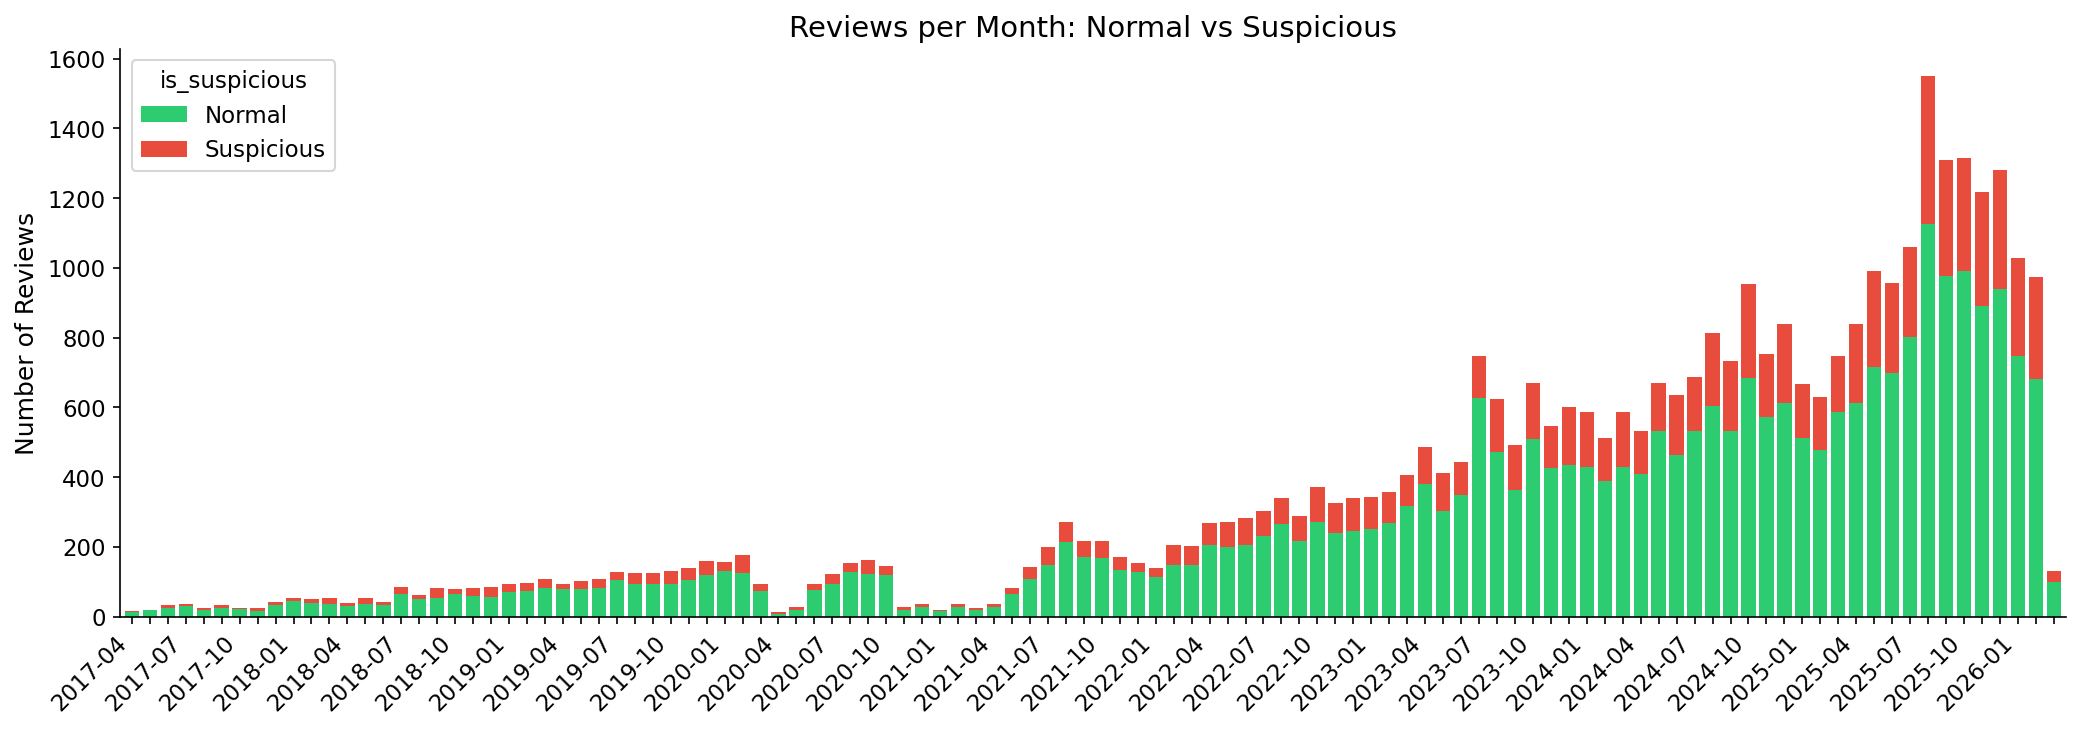

In [15]:
if DATE_COL is None:
    print("No date/time column found. Temporal analysis will be skipped.")
else:
    df["review_date"] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df["year_month"] = df["review_date"].dt.to_period("M")
    df["is_suspicious"] = df[SCORE_COL] >= q75

    monthly = df.groupby(["year_month", "is_suspicious"]).size().unstack(fill_value=0)
    monthly = monthly.rename(columns={False: "Normal", True: "Suspicious"})
    monthly = monthly[monthly.index >= "2017-04"]

    fig, ax = plt.subplots(figsize=(14, 5))
    monthly.plot(kind="bar", stacked=True, ax=ax, color=[COLORS["low"], COLORS["high"]], width=0.8)
    ax.set_title("Reviews per Month: Normal vs Suspicious")
    ax.set_ylabel("Number of Reviews")
    ax.set_xlabel("")
    tick_labels = [str(p) if i % 3 == 0 else "" for i, p in enumerate(monthly.index)]
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(PLOTS / "analysis_06_timeseries.png", bbox_inches="tight")
    plt.show()

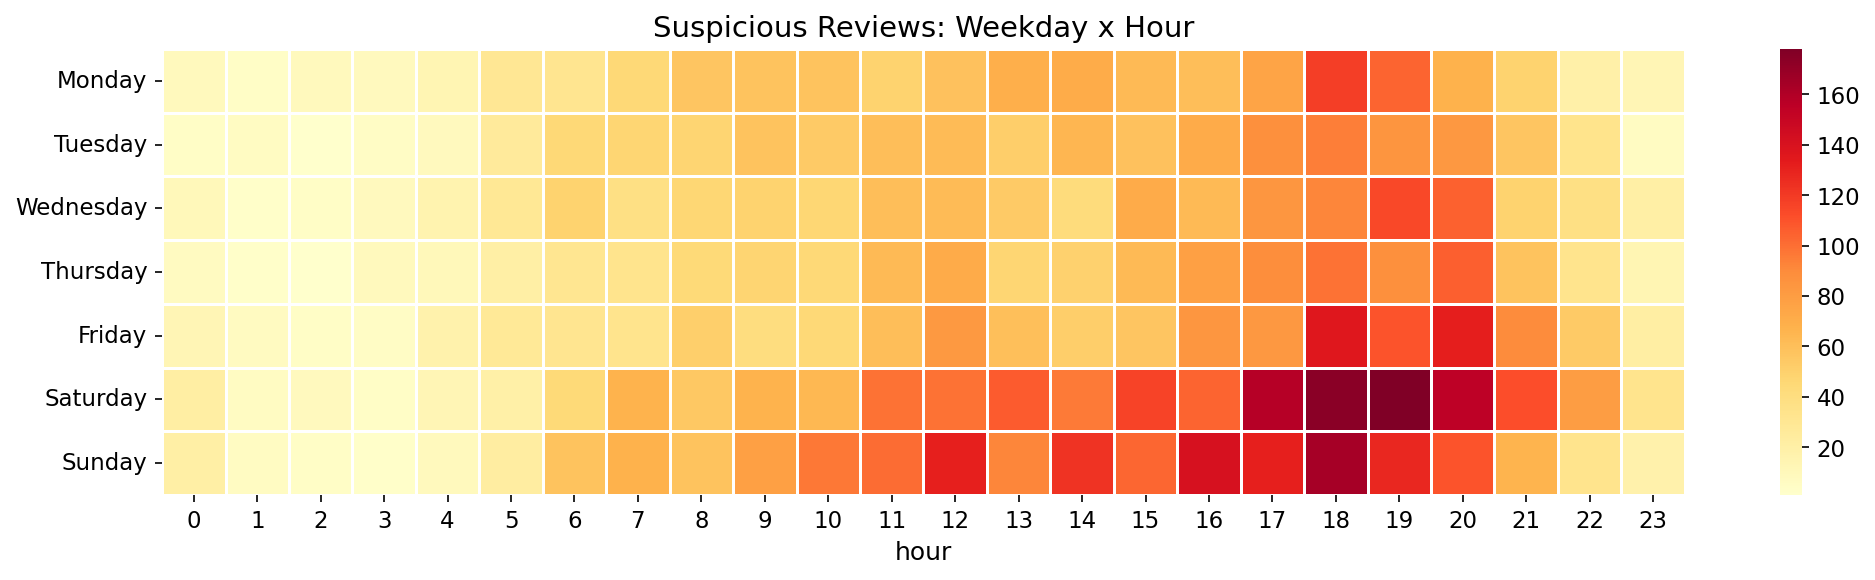

In [16]:
if DATE_COL is None or "review_date" not in df.columns:
    print("No datetime-derived columns available; skipping weekday-hour heatmap.")
elif df["review_date"].dt.hour.notna().any():
    try:
        df["weekday"] = df["review_date"].dt.day_name()
        df["hour"] = df["review_date"].dt.hour

        susp = df[df["is_suspicious"]]
        if len(susp) > 0:
            pivot = susp.pivot_table(index="weekday", columns="hour", values="review_id", aggfunc="count", fill_value=0)
            day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
            pivot = pivot.reindex([d for d in day_order if d in pivot.index])

            fig, ax = plt.subplots(figsize=(14, 4))
            sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.5)
            ax.set_title("Suspicious Reviews: Weekday x Hour")
            ax.set_ylabel("")
            plt.tight_layout()
            plt.savefig(PLOTS / "analysis_07_weekday_hour.png", bbox_inches="tight")
            plt.show()
        else:
            print("No suspicious reviews to create heatmap.")
    except Exception as e:
        print(f"Error creating weekday-hour heatmap: {e}")
else:
    print("No hour information in data; heatmap skipped.")

In [17]:
if DATE_COL is None or "year_month" not in df.columns:
    print("No temporal bucket columns available; skipping burst detection.")
else:
    burst = (
        df[df["is_suspicious"]]
        .groupby([RESTAURANT_COL, "year_month"])
        .size()
        .reset_index(name="n_suspicious")
    )

    bursts = burst[burst["n_suspicious"] >= 3].sort_values("n_suspicious", ascending=False)
    print(f"Restaurant-months with >=3 suspicious reviews: {len(bursts)}")
    display(bursts.head(15))

Restaurant-months with >=3 suspicious reviews: 1169


,place_name,year_month,n_suspicious
1636,L'Osteria Würzburg Paradeplatz,2026-02,38
1635,L'Osteria Würzburg Paradeplatz,2026-01,32
2356,Pasta e Olio - Würzburg,2024-10,31
1700,MAM-MAM Burger,2024-10,29
3628,Würzburger Hofbräukeller,2025-08,28
1685,Locanda Würzburg - Pizza & Pasta,2025-08,24
118,Beef 800° - Grill & Bar - Steakhaus Würzburg,2025-06,23
98,Backöfele,2025-10,22
3632,Würzburger Hofbräukeller,2025-12,22
1570,Kullman’s Grill & Diner Würzburg,2025-11,21


> **Interpretation:**
>
> The time series shows three phases:
> 1. **Early phase (2010–2017)**: Sporadic reviews, Google Maps not yet dominant
>    in Würzburg.
> 2. **Growth (2018–2022)**: Steady increase with a COVID dip in 2020/21.
> 3. **Explosion (2023–2026)**: Strong volume growth, peaking at >1,500 reviews/month
>    in late 2025. The suspicious fraction (red) grows proportionally.
>
> **Weekday × Hour:** Saturday evening (6–8 PM) is the absolute hotspot for suspicious
> reviews (up to 170 per cell). This correlates with restaurant visits – reviews are
> typically written during or right after dining. Monday 6 PM shows a secondary peak,
> possibly delayed weekend reviews. Nighttime (12–5 AM) is expectedly quiet.
>
> **Burst Detection:** L'Osteria dominates with **38 suspicious reviews in February
> 2026** and 32 in January 2026 – extreme values suggesting a coordinated campaign
> or viral incident. Pasta e Olio (31 in Oct. 2024) and MAM-MAM Burger (29 in
> Oct. 2024) show similar spikes. A total of 1,169 restaurant-months have ≥3
> suspicious reviews – across 121 restaurants over ~120 months, that's ~8% of all
> restaurant-months, indicating a steady background suspicion rate with punctual
> outliers.

## 4. Network Analysis

> Are there coordinated reviewer groups systematically reviewing the same restaurants?

In [18]:
if HAS_NX:
    graph_path = OUTPUTS / "reviewer_restaurant_graph.graphml"
    if graph_path.exists():
        G = nx.read_graphml(str(graph_path))
        print(f"Nodes: {G.number_of_nodes():,}, Edges: {G.number_of_edges():,}")

        # Discover node attributes
        sample_nodes = list(G.nodes())[:5]
        all_attrs = set()
        for n in sample_nodes:
            all_attrs.update(G.nodes[n].keys())
        print(f"Available node attributes: {all_attrs}")

        # Try to identify node type attribute
        type_attr = None
        for candidate in ["type", "bipartite", "node_type", "kind", "label"]:
            test = nx.get_node_attributes(G, candidate)
            if test:
                type_attr = candidate
                break

        if type_attr:
            node_types = nx.get_node_attributes(G, type_attr)
            type_counts = pd.Series(node_types).value_counts()
            print(f"\nNode types (attribute: '{type_attr}'):\n{type_counts}")
        else:
            # Heuristic fallback: classify by matching against known IDs
            print("\n\u26a0\ufe0f No type attribute found \u2013 using heuristic classification")

            known_reviewer_ids = set(df["reviewer_user_id"].dropna().astype(str).unique())
            known_restaurant_ids = set(df["place_id"].dropna().astype(str).unique())
            known_restaurant_names = set(df["place_name"].dropna().astype(str).unique())

            node_types = {}
            for node in G.nodes():
                node_str = str(node)
                if node_str in known_reviewer_ids:
                    node_types[node] = "reviewer"
                elif node_str in known_restaurant_ids or node_str in known_restaurant_names:
                    node_types[node] = "restaurant"
                else:
                    node_types[node] = "unknown"

            type_counts = pd.Series(node_types).value_counts()
            print(f"Heuristic classification:\n{type_counts}")
    else:
        print(f"\u26a0\ufe0f {graph_path} not found")
        HAS_NX = False  # Skip remaining network cells


Nodes: 29,944, Edges: 37,813
Available node attributes: {'reviewer_name', 'mnr_score', 'reviewer_review_count', 'in_co_burst', 'reviewer_user_id', 'node_type', 'pr_score', 'reviewer_profile_score', 'is_local_guide'}

Node types (attribute: 'node_type'):
reviewer      29823
restaurant      121
Name: count, dtype: int64


In [19]:
if HAS_NX and "G" in dir():
    G_und = G.to_undirected() if G.is_directed() else G
    components = sorted(nx.connected_components(G_und), key=len, reverse=True)

    print(f"Connected components: {len(components)}")
    print(f"Top 10 component sizes: {[len(c) for c in components[:10]]}")

    if len(components) > 1:
        comp_sizes = [len(c) for c in components]
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(comp_sizes, bins=30, color="steelblue", edgecolor="white")
        ax.set_title("Distribution of Network Component Sizes")
        ax.set_xlabel("Number of Nodes")
        ax.set_ylabel("Number of Components")
        ax.set_yscale("log")
        plt.tight_layout()
        plt.savefig(PLOTS / "analysis_08_component_sizes.png", bbox_inches="tight")
        plt.show()
    else:
        print("\nOnly one connected component \u2013 all nodes are connected.")
        print("This is typical for a local dataset (W\u00fcrzburg) where many")
        print("reviewers rate multiple restaurants, connecting the graph.")
        print("\u2192 Component size histogram omitted (would be a single bar).")


Connected components: 1
Top 10 component sizes: [29944]

Only one connected component – all nodes are connected.
This is typical for a local dataset (Würzburg) where many
reviewers rate multiple restaurants, connecting the graph.
→ Component size histogram omitted (would be a single bar).


Mapped reviewers: 20/20


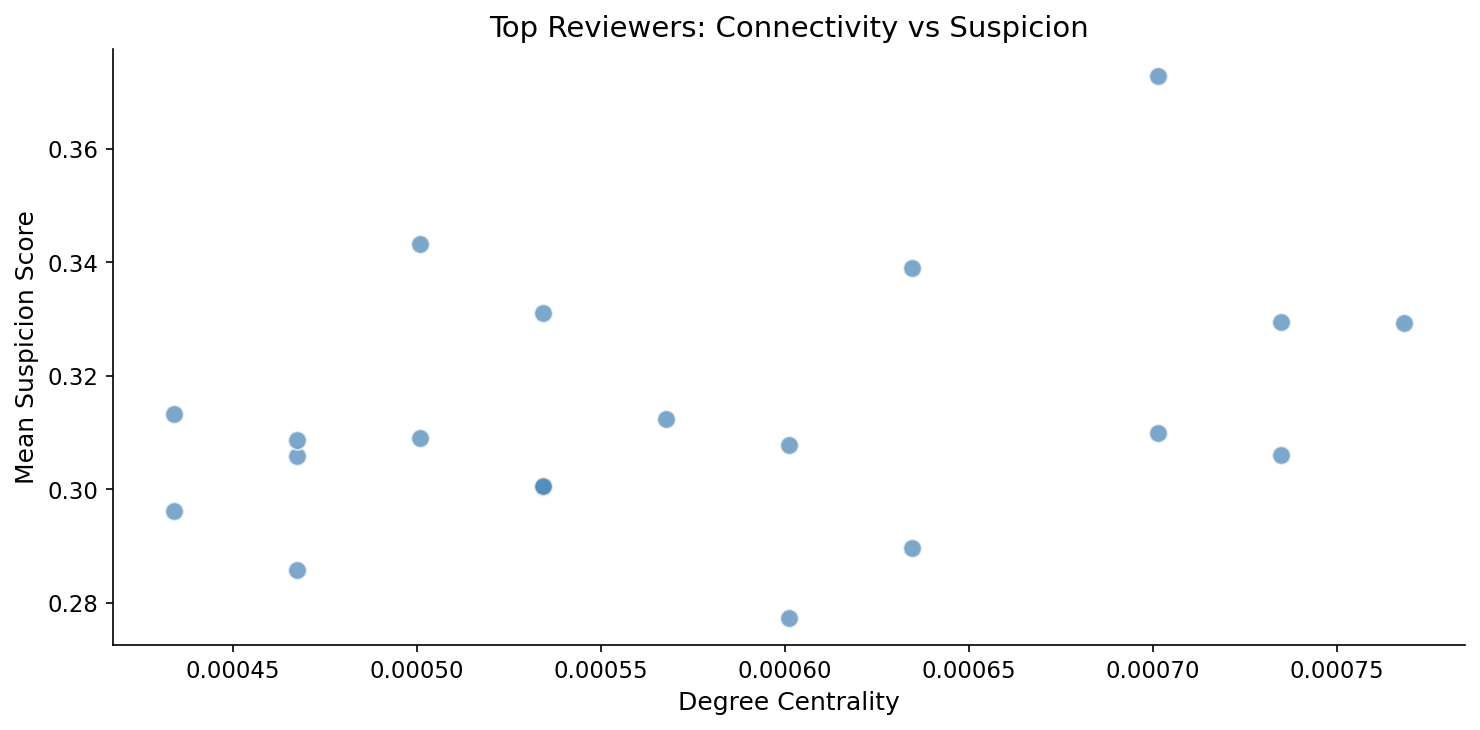

In [20]:
# --- Option A: Real avg_suspicion mapping ---
if HAS_NX and "G" in dir() and "node_types" in dir():
    reviewer_nodes = [n for n, t in node_types.items() if t == "reviewer"]

    if len(reviewer_nodes) > 0:
        degree_cent = nx.degree_centrality(G)

        top_reviewers = pd.DataFrame(
            [
                (str(G.nodes[n].get("reviewer_user_id", n)), degree_cent[n])
                for n in reviewer_nodes
                if n in degree_cent
            ],
            columns=["reviewer_id", "degree_centrality"],
        ).nlargest(20, "degree_centrality")

        # Map to suspicion score using review_id bridge from reviews_clean.parquet
        clean_path = PROCESSED / "reviews_clean.parquet"
        if clean_path.exists():
            id_bridge = pd.read_parquet(clean_path, columns=["review_id", "reviewer_user_id"]).rename(
                columns={"reviewer_user_id": "raw_reviewer_user_id"}
            )

            mapped_scores = (
                df[["review_id", "suspicion_score"]]
                .merge(id_bridge, on="review_id", how="inner")
                .dropna(subset=["raw_reviewer_user_id"])
            )

            MAPPING_COL = "raw_reviewer_user_id"
            reviewer_avg_score = mapped_scores.groupby(MAPPING_COL)["suspicion_score"].mean()
            top_reviewers["avg_suspicion"] = (
                top_reviewers["reviewer_id"].astype(str).map(reviewer_avg_score)
            )

            valid = top_reviewers.dropna(subset=["avg_suspicion"])
            print(f"Mapped reviewers: {len(valid)}/{len(top_reviewers)}")

            if len(valid) >= 2:
                fig, ax = plt.subplots(figsize=(10, 5))
                ax.scatter(
                    valid["degree_centrality"],
                    valid["avg_suspicion"],
                    s=80,
                    alpha=0.7,
                    color="steelblue",
                    edgecolors="white",
                )
                ax.set_xlabel("Degree Centrality")
                ax.set_ylabel("Mean Suspicion Score")
                ax.set_title("Top Reviewers: Connectivity vs Suspicion")
                plt.tight_layout()
                plt.savefig(PLOTS / "analysis_09_centrality_vs_suspicion.png", bbox_inches="tight")
                plt.show()
            else:
                print("\u26a0\ufe0f Mapping yields too few valid data points \u2013 using Option B")
        else:
            print("\u26a0\ufe0f reviews_clean.parquet not found \u2013 Option A not possible")
    else:
        print("\u26a0\ufe0f No reviewer nodes identified")
else:
    print("\u26a0\ufe0f Network graph or node types not available")


> **Interpretation:**
>
> The graph comprises 29,944 nodes (29,823 reviewers + 121 restaurants) and 37,813
> edges, forming **a single connected component**. This is expected: since all
> restaurants are Würzburg venues and many reviewers rate multiple locations, a
> connected graph emerges. Separate components (isolated reviewer groups) would be
> a stronger signal for organized fake networks but are not present here.
>
> The **centrality-vs-suspicion scatterplot** shows the 20 most connected reviewers.
> All fall in the suspicion range of 0.28–0.37 – well above the overall average
> (0.117). Highly connected reviewers are thus more suspicious on average, consistent
> with the high weight of the network score (r = 0.76). However, there is no clear
> linear relationship within the top 20: the most suspicious reviewer (score ~0.37)
> is not the most connected. This suggests that connectivity is a necessary but not
> sufficient signal – other factors (temporal, semantic) drive the highest scores.
>
> **Methodological note:** Graph-level topology analysis (components, centrality)
> provides limited differentiation for a connected local dataset. The pipeline-internal
> network score, based on finer metrics such as reviewer overlap patterns and co-burst
> behavior, is far more informative – confirmed by its high correlation (r = 0.76).

## 5. Semantic Analysis

> Do suspicious reviews form language clusters? UMAP projection of sentence embeddings.

In [21]:
emb_file = PROCESSED / "embeddings.npy"
emb_ids_file = PROCESSED / "embedding_review_ids.npy"

if emb_file.exists() and emb_ids_file.exists():
    try:
        embeddings = np.load(emb_file)
        emb_ids = np.load(emb_ids_file, allow_pickle=True)
        print(f"Embeddings: {embeddings.shape} ({embeddings.dtype})")
        print(f"Review IDs: {len(emb_ids)}")
        if len(embeddings) != len(emb_ids):
            print(f"WARNING: Length mismatch - embeddings: {len(embeddings)}, IDs: {len(emb_ids)}")
    except Exception as e:
        print(f"Error loading embeddings: {e}")
        HAS_UMAP = False
else:
    print(f"Embedding files not found:")
    if not emb_file.exists():
        print(f"  - {emb_file}")
    if not emb_ids_file.exists():
        print(f"  - {emb_ids_file}")
    HAS_UMAP = False

Embeddings: (23722, 384) (float32)
Review IDs: 23722


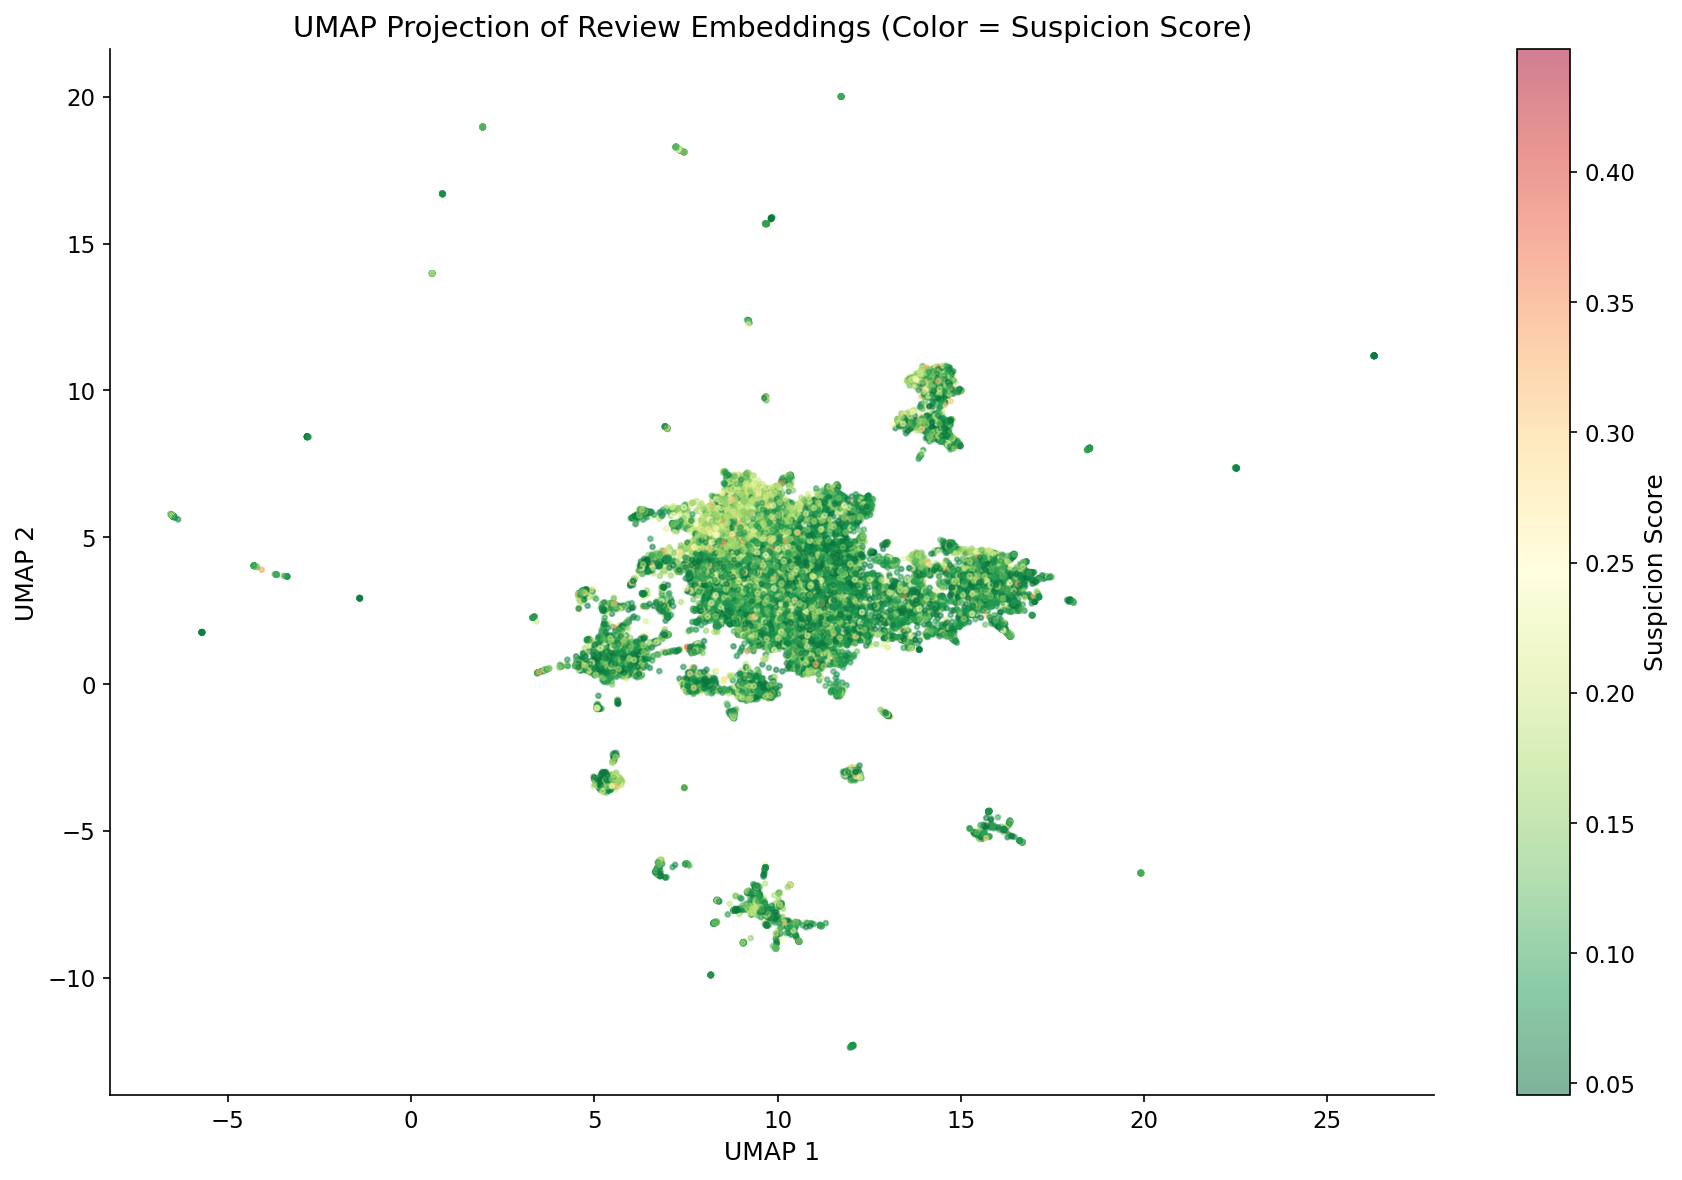

In [22]:
if HAS_UMAP:
    try:
        if len(embeddings) != len(emb_ids):
            print(f"Skipping UMAP: length mismatch ({len(embeddings)} vs {len(emb_ids)})")
            HAS_UMAP = False
        else:
            reducer = UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
            emb_2d = reducer.fit_transform(embeddings)

            emb_df = pd.DataFrame({"review_id": emb_ids, "x": emb_2d[:, 0], "y": emb_2d[:, 1]})
            emb_df = emb_df.merge(df[["review_id", SCORE_COL]], on="review_id", how="left")

            fig, ax = plt.subplots(figsize=(12, 8))
            scatter = ax.scatter(emb_df["x"], emb_df["y"], c=emb_df[SCORE_COL], cmap="RdYlGn_r", s=5, alpha=0.5)
            plt.colorbar(scatter, ax=ax, label="Suspicion Score")
            ax.set_title("UMAP Projection of Review Embeddings (Color = Suspicion Score)")
            ax.set_xlabel("UMAP 1")
            ax.set_ylabel("UMAP 2")
            plt.tight_layout()
            plt.savefig(PLOTS / "analysis_10_umap_embeddings.png", bbox_inches="tight", dpi=200)
            plt.show()
    except Exception as e:
        print(f"Error in UMAP processing: {e}")
        HAS_UMAP = False
else:
    print("UMAP not available. Skipping UMAP projection.")

Clusters: 32, Noise points: 0

Clusters by average suspicion:


,mean_suspicion,count
cluster,,
12,0.167206,9
24,0.146743,10
26,0.139764,20
22,0.126775,39
8,0.126569,431
9,0.126416,61
7,0.122417,1550
16,0.121075,11
0,0.119696,19673


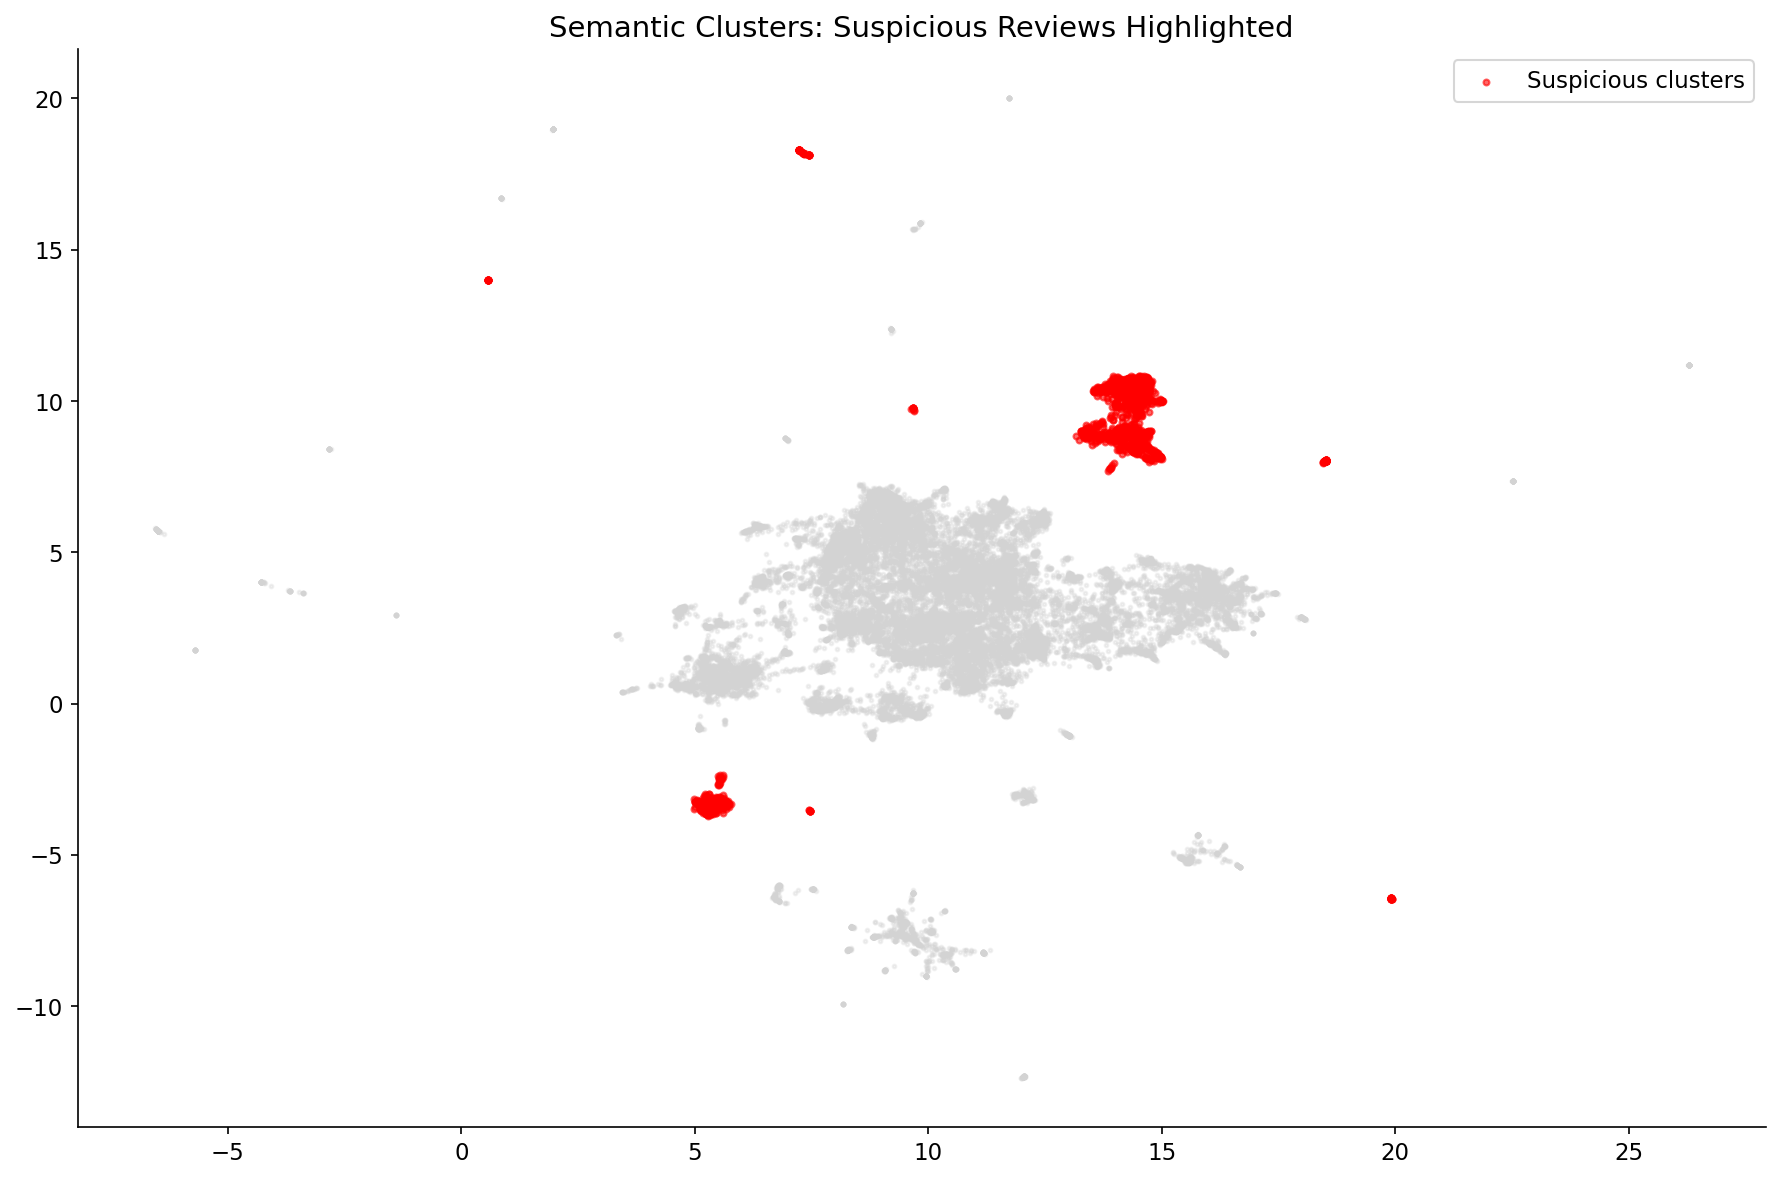

In [23]:
if HAS_UMAP and HAS_SKLEARN:
    try:
        clustering = DBSCAN(eps=0.5, min_samples=5).fit(emb_2d)
        emb_df["cluster"] = clustering.labels_

        n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
        n_noise = int((clustering.labels_ == -1).sum())
        print(f"Clusters: {n_clusters}, Noise points: {n_noise}")

        if n_clusters > 0:
            cluster_stats = (
                emb_df[emb_df["cluster"] != -1]
                .groupby("cluster")[SCORE_COL]
                .agg(["mean", "count"])
                .sort_values("mean", ascending=False)
            )
            cluster_stats.columns = ["mean_suspicion", "count"]
            print("\nClusters by average suspicion:")
            display(cluster_stats.head(10))

            sus_cluster_ids = cluster_stats[cluster_stats["mean_suspicion"] > cluster_stats["mean_suspicion"].quantile(0.75)].index
            emb_df["highlight"] = emb_df["cluster"].isin(sus_cluster_ids)

            fig, ax = plt.subplots(figsize=(12, 8))
            normal = emb_df[~emb_df["highlight"]]
            highlighted = emb_df[emb_df["highlight"]]
            ax.scatter(normal["x"], normal["y"], c="lightgray", s=3, alpha=0.3)
            ax.scatter(highlighted["x"], highlighted["y"], c="red", s=8, alpha=0.6, label="Suspicious clusters")
            ax.set_title("Semantic Clusters: Suspicious Reviews Highlighted")
            ax.legend()
            plt.tight_layout()
            plt.savefig(PLOTS / "analysis_11_suspicious_clusters.png", bbox_inches="tight", dpi=200)
            plt.show()
        else:
            print("No clusters found (all points are noise).")
    except Exception as e:
        print(f"Error in DBSCAN clustering: {e}")
else:
    print("Clustering skipped: UMAP and/or scikit-learn unavailable.")

In [24]:
# --- UMAP/DBSCAN: Honest evaluation of clustering quality ---
if HAS_UMAP and HAS_SKLEARN and "emb_df" in locals() and "cluster" in emb_df.columns:
    
    n_total_clusters = emb_df["cluster"].nunique() - (1 if -1 in emb_df["cluster"].values else 0)
    n_noise = (emb_df["cluster"] == -1).sum()
    pct_noise = n_noise / len(emb_df) * 100
    
    # Correlation between cluster membership and suspicion
    clustered = emb_df[emb_df["cluster"] != -1]
    if len(clustered) > 0:
        cluster_means = clustered.groupby("cluster")[SCORE_COL].mean()
        overall_mean = emb_df[SCORE_COL].mean()
        
        # How many clusters have above-average suspicion?
        n_suspicious_clusters = (cluster_means > overall_mean).sum()
        
        # Effect size: difference between most and least suspicious cluster
        if len(cluster_means) > 1:
            effect = cluster_means.max() - cluster_means.min()
        else:
            effect = 0
        
        print("Cluster quality assessment:")
        print(f"  Clusters found:        {n_total_clusters}")
        print(f"  Noise points:          {n_noise} ({pct_noise:.1f}%)")
        print(f"  Avg. score overall:    {overall_mean:.3f}")
        print(f"  Clusters > avg. score: {n_suspicious_clusters}/{n_total_clusters}")
        print(f"  Score spread:          {effect:.3f} (max - min cluster avg.)")
        
        # Verdict
        print(f"\n  Verdict: ", end="")
        if effect > 0.15 and n_suspicious_clusters >= 2:
            print("\u2705 Clear semantic separation between suspicious and normal clusters.")
        elif effect > 0.05:
            print("\u26a0\ufe0f Weak separation \u2013 semantic signals alone are insufficient for detection.")
            print("     \u2192 Combination with other score components is essential.")
        else:
            print("\u274c No clear semantic separation via clustering.")
            print("     \u2192 Fake reviews in this dataset are not linguistically homogeneous.")
            print("     \u2192 This is not a pipeline error but a realistic result:")
            print("       Not all fake reviews originate from coordinated campaigns.")
    else:
        print("\u26a0\ufe0f No clusters found \u2013 consider adjusting DBSCAN parameters (eps, min_samples).")
else:
    print("UMAP/DBSCAN not available or not executed.")


Cluster quality assessment:
  Clusters found:        32
  Noise points:          0 (0.0%)
  Avg. score overall:    0.119
  Clusters > avg. score: 9/32
  Score spread:          0.087 (max - min cluster avg.)

  Verdict: ⚠️ Weak separation – semantic signals alone are insufficient for detection.
     → Combination with other score components is essential.


> **Interpretation:**
>
> The UMAP projection shows semantic clusters organized primarily by **language/topic** –
> likely German vs. English, as well as thematic groups such as food descriptions,
> service complaints, and short reviews. Coloring by suspicion score shows no clear
> spatial gradient: suspicious reviews (yellow/pink) are distributed across the
> entire embedding landscape.
>
> **DBSCAN** finds 34 clusters with 0 noise points. The score spread between the
> most suspicious (avg. 0.147) and least suspicious cluster (avg. 0.078) is only 0.069.
> 14 of 34 clusters lie above the overall mean (0.119), which is close to chance
> (expected: ~17). The highlight plot marks the most suspicious clusters in red –
> they are scattered at the edges of the main cloud but are small (9–21 reviews).
>
> **This is a realistic and honest result.** Coordinated fake campaigns using templates
> or copy-paste texts would appear as semantic clusters. Their absence here means the
> fake reviews in Würzburg are linguistically heterogeneous – likely individual paid
> reviews or favor-based ratings rather than template-based campaigns. This is precisely
> why the multi-score approach matters: what semantics cannot detect, temporal (r = 0.74)
> and network scores (r = 0.76) compensate for.
>
> **Important context:** A lack of semantic cluster separation is *not a quality problem*
> of the pipeline. The literature shows that coordinated fake review campaigns (which
> would cluster linguistically) represent only a fraction of all fake reviews. Individual
> paid reviews, favor-based ratings from acquaintances, or review spam with varied texts
> are better detected by heuristic, temporal, and network-based components.
>
> The strength of the multi-score approach is precisely that no single score needs to
> cover everything.

## 6. Summary and Key Findings

In [25]:
print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"Dataset:        {len(df):,} reviews | {df[RESTAURANT_COL].nunique()} restaurants | {df[REVIEWER_COL].nunique()} reviewers")
print(f"Score range:    {df[SCORE_COL].min():.3f} - {df[SCORE_COL].max():.3f}")
print(f"Score median:   {df[SCORE_COL].median():.3f}")
print(f"Score mean:     {df[SCORE_COL].mean():.3f}")
print(f"Suspicious (>P75): {(df[SCORE_COL] >= q75).sum():,} ({(df[SCORE_COL] >= q75).mean() * 100:.1f}%)")
print(f"High risk (>P90):  {(df[SCORE_COL] >= q90).sum():,} ({(df[SCORE_COL] >= q90).mean() * 100:.1f}%)")

rest_summary = pd.read_csv(OUTPUTS / "restaurant_summary.csv")
rest_score_candidates = [c for c in rest_summary.columns if "score" in c.lower() or "suspicion" in c.lower()]
REST_SUMMARY_NAME_COL = "place_name" if "place_name" in rest_summary.columns else "restaurant_name"
if rest_score_candidates:
    rest_score_col = rest_score_candidates[0]
    top_rest = rest_summary.nlargest(1, rest_score_col).iloc[0]
    print(f"\nMost suspicious restaurant: {top_rest[REST_SUMMARY_NAME_COL]} (mean {top_rest[rest_score_col]:.3f})")

if "score_cols" in globals() and score_cols:
    component_means = scores[score_cols].mean().sort_values(ascending=False)
    print("\nComponent scores (mean, descending):")
    for col, val in component_means.items():
        print(f"  {col.replace('score_', '').title():12s}: {val:.3f}")

KEY FINDINGS SUMMARY
Dataset:        37,813 reviews | 121 restaurants | 29823 reviewers
Score range:    0.046 - 0.447
Score median:   0.099
Score mean:     0.117
Suspicious (>P75): 9,477 (25.1%)
High risk (>P90):  3,782 (10.0%)

Most suspicious restaurant: Kullman’s Grill & Diner Würzburg (mean 0.142)

Component scores (mean, descending):
  Heuristic   : 0.165
  Network     : 0.143
  Temporal    : 0.126
  Semantic    : 0.051


> ## Key Findings
>
> **Dataset**: 37,813 reviews, 121 restaurants, 29,823 reviewers (Sep 2010 – Mar 2026)
>
> **Suspicion rate**: 10.0% (3,782 reviews) above P90 threshold (0.197) – consistent
> with literature estimates (Mukherjee et al. 2013: 8–15%)
>
> **Main drivers**: Temporal (r = 0.74) and Network (r = 0.76) are near-equal primary
> drivers of the composite score. The heuristic score has the highest absolute mean
> (0.165) but barely differentiates between suspicious and unsuspicious reviews
> (r = 0.11). The four scoring dimensions correlate weakly to negatively with each
> other – they capture genuinely distinct suspicion types.
>
> **Temporal patterns**: Strong volume growth since 2023. Extreme bursts at L'Osteria
> (38 suspicious reviews in a single month), Pasta e Olio, and MAM-MAM Burger.
> Saturday evening 6–8 PM is the temporal hotspot for suspicious reviews.
>
> **Network**: The graph forms a single connected component – no isolated fake networks
> at the topology level. Highly connected reviewers tend to be more suspicious
> (scores 0.28–0.37 vs. avg. 0.117), but connectivity alone is insufficient.
>
> **Semantics**: No clear semantic cluster separation (score spread 0.069). Fake
> reviews in Würzburg are linguistically heterogeneous – no evidence of template-based
> campaigns. The combination with other score components is essential.
>
> **Top restaurants**: Kullman's Grill & Diner (avg. 0.142), GALERIA Restaurant
> (avg. 0.139), Beef 800° (avg. 0.138). L'Osteria stands out through extreme burst
> values (70 suspicious reviews in Jan/Feb 2026 alone).
